# 🛒 Visual Product Search — Eval C
EVAL C: Fine-tuned CLIP + Captions (Ablation C)
Requires:
- DeepFashion base dataset
- Part 1 output (captions_cache.json)
- Part 2 output (clip_seed*.pt checkpoints)

Run this in parallel with eval_ab.py.
Saves results to eval_c_results.json for final_compare.py.


In [1]:
# ── Install ──
import subprocess, sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q',
    'ultralytics', 'hnswlib', 'open_clip_torch', 'transformers', 'accelerate'])

import os, torch, random, json, shutil, numpy as np, pandas as pd
from tqdm import tqdm
from PIL import Image
import torch.nn.functional as F


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 20.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 60.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.0 MB/s eta 0:00:00


In [2]:
# ── Config ──
# ⚠️ UPDATE THESE paths to match your input datasets
PART1_DIR = '/kaggle/input/datasets/chandrahas7c/pipeline-v1-dataset'
PART2_DIR = '/kaggle/input/datasets/chandrahas7c/pipeline-v1-dataset'
BASE_INPUT = '/kaggle/input/datasets/sartma/deepfashion-inshop'
EVAL_FILE = f'{BASE_INPUT}/Eval/list_eval_partition.txt'
WORK = '/kaggle/working'
RESULTS_FILE = f'{WORK}/eval_c_results.json'
os.makedirs(WORK, exist_ok=True)

# Copy artifacts from Part 1 (captions)
print("Copying artifacts from Part 1...")
if os.path.exists(PART1_DIR):
    for f in os.listdir(PART1_DIR):
        if f == 'captions_cache.json':
            shutil.copy(os.path.join(PART1_DIR, f), os.path.join(WORK, f))
            print(f"  Copied {f}")
else:
    print(f"⚠️ PART1_DIR not found: {PART1_DIR}. Please update the path!")

# Copy checkpoints from Part 2
print("Copying checkpoints from Part 2...")
if os.path.exists(PART2_DIR):
    for f in os.listdir(PART2_DIR):
        if f.endswith('.pt'):
            shutil.copy(os.path.join(PART2_DIR, f), os.path.join(WORK, f))
            print(f"  Copied {f}")
else:
    print(f"⚠️ PART2_DIR not found: {PART2_DIR}. Please update the path!")

IMG_ROOT = None
for c in [f'{BASE_INPUT}/img/img', f'{BASE_INPUT}/img']:
    if os.path.isdir(f'{c}/MEN') or os.path.isdir(f'{c}/WOMEN'):
        IMG_ROOT = c; break

SEEDS = [14, 37, 106]
ALPHA_VALUES = [0.3, 0.7]
K_VALUES = [5, 10, 15]
RERANK_K = 15
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

def set_seed(s):
    random.seed(s); np.random.seed(s); torch.manual_seed(s)
    torch.cuda.manual_seed_all(s); torch.backends.cudnn.deterministic = True


Copying artifacts from Part 1...
  Copied captions_cache.json
Copying checkpoints from Part 2...
  Copied clip_seed106.pt
  Copied clip_seed37.pt
  Copied clip_seed14.pt


In [3]:
# ── Parse splits ──
with open(EVAL_FILE) as f: lines = f.readlines()
data = [l.strip().split() for l in lines[2:] if l.strip()]
df = pd.DataFrame(data, columns=['image_name','item_id','split'])
df['full_path'] = df['image_name'].apply(lambda x: os.path.join(IMG_ROOT, x.replace('img/','',1)))
query_df = df[df.split=='query'].reset_index(drop=True)
gallery_df = df[df.split=='gallery'].reset_index(drop=True)
print(f'Query:{len(query_df)} Gallery:{len(gallery_df)}')


Query:14218 Gallery:12612


In [4]:
# ── Load Captions ──
with open(f'{WORK}/captions_cache.json') as f: captions = json.load(f)
print(f'Loaded {len(captions)} captions')


Loaded 26830 captions


In [5]:
# ── YOLO ──
from ultralytics import YOLO
yolo_model = YOLO('/kaggle/input/models/sartma/yolo-finetune-inshop/pytorch/default/1/best.pt')

def yolo_crop(path, model, pad=10):
    img = Image.open(path).convert('RGB')
    try:
        res = model(path, verbose=False); boxes = res[0].boxes
        if len(boxes)==0: return img
        best = max(boxes, key=lambda b: (b.xyxy[0][2]-b.xyxy[0][0])*(b.xyxy[0][3]-b.xyxy[0][1]))
        x1,y1,x2,y2 = map(int, best.xyxy[0]); W,H = img.size
        return img.crop((max(0,x1-pad),max(0,y1-pad),min(W,x2+pad),min(H,y2+pad)))
    except: return img


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [6]:
# ── CLIP ──
import open_clip
def load_clip(ckpt=None):
    m, _, p = open_clip.create_model_and_transforms('ViT-B-32', pretrained='openai')
    if ckpt and os.path.exists(ckpt):
        m.load_state_dict(torch.load(ckpt, map_location='cpu'))
        print(f'  Loaded checkpoint: {ckpt}')
    m = m.to(DEVICE).eval()
    tok = open_clip.get_tokenizer('ViT-B-32')
    return m, p, tok

clip_tokenizer = open_clip.get_tokenizer('ViT-B-32')

def get_image_emb(pil, model, preprocess):
    x = preprocess(pil).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        e = model.encode_image(x); e = e/e.norm(dim=-1,keepdim=True)
    return e.cpu().float().numpy()[0]

def get_text_emb(text, model):
    t = clip_tokenizer([text]).to(DEVICE)
    with torch.no_grad():
        e = model.encode_text(t); e = e/e.norm(dim=-1,keepdim=True)
    return e.cpu().float().numpy()[0]

def fuse(img_e, txt_e, alpha):
    v = alpha*img_e + (1-alpha)*txt_e
    return v/(np.linalg.norm(v)+1e-8)


In [7]:
# ── BLIP ITM ──
from transformers import BlipProcessor, BlipForImageTextRetrieval
print('Loading BLIP ITM...')
itm_proc = BlipProcessor.from_pretrained('Salesforce/blip-itm-base-coco')
itm_mdl = BlipForImageTextRetrieval.from_pretrained('Salesforce/blip-itm-base-coco', torch_dtype=torch.float16).to(DEVICE).eval()


Loading BLIP ITM...


preprocessor_config.json:   0%|          | 0.00/445 [00:00<?, ?B/s]

The image processor of type `BlipImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/456 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/895M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/472 [00:00<?, ?it/s]

BlipForImageTextRetrieval LOAD REPORT from: Salesforce/blip-itm-base-coco
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_encoder.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/895M [00:00<?, ?B/s]

In [8]:
# ── Metrics ──
gallery_item_counts = gallery_df.groupby('item_id').size().to_dict()

def hit_at_k(ret, rel, k): return 1.0 if len(set(ret[:k])&rel) > 0 else 0.0
def recall_at_k(ret, rel, k, nr):
    hits = sum(1 for r in ret[:k] if r in rel)
    return hits / nr if nr > 0 else 0.0
def ndcg_at_k(ret, rel, k, nr):
    d = sum(1/np.log2(i+2) for i,r in enumerate(ret[:k]) if r in rel)
    ideal = sum(1/np.log2(i+2) for i in range(min(nr,k)))
    return d/ideal if ideal>0 else 0.0
def map_at_k(ret, rel, k, nr):
    h,s = 0,0.0
    for i,r in enumerate(ret[:k]):
        if r in rel: h+=1; s+=h/(i+1)
    return s/nr if nr>0 else 0.0


In [9]:
# ── Build index + evaluate ──
import hnswlib

def build_index(gdf, cm, cp, alpha, caps, name):
    ep = f'{WORK}/emb_{name}.npy'; mp = f'{WORK}/meta_{name}.json'; ip = f'{WORK}/hnsw_{name}.index'
    if os.path.exists(ep) and os.path.exists(mp):
        embs = np.load(ep)
        with open(mp) as f: meta = json.load(f)
        print(f'  [{name}] Loaded {embs.shape} from cache')
    else:
        embs, meta = [], []
        for _, row in tqdm(gdf.iterrows(), total=len(gdf), desc=f'  [{name}]'):
            try:
                crop = yolo_crop(row['full_path'], yolo_model)
                ie = get_image_emb(crop, cm, cp)
                if alpha==1.0: final=ie
                else: final=fuse(ie, get_text_emb(caps.get(row['image_name'],'clothing item'), cm), alpha)
                embs.append(final)
                meta.append({'idx':len(embs)-1,'image_name':row['image_name'],'item_id':row['item_id'],'full_path':row['full_path']})
            except: pass
        embs = np.array(embs, dtype=np.float32)
        np.save(ep, embs); 
        with open(mp,'w') as f: json.dump(meta,f)
        print(f'  [{name}] Done {embs.shape}')
    idx = hnswlib.Index(space='cosine', dim=embs.shape[1])
    if os.path.exists(ip): 
        idx.load_index(ip)
    else:
        idx.init_index(max_elements=len(embs), ef_construction=200, M=16)
        idx.add_items(embs, np.arange(len(embs))); idx.save_index(ip)
    idx.set_ef(50)
    return idx, meta

def itm_rerank(qcrop, cands, meta, caps):
    if not caps: return cands
    valid_caps, valid_indices = [], []
    for i, l in enumerate(cands):
        cap = caps.get(meta[l]['image_name'], '')
        if cap:
            valid_caps.append(cap)
            valid_indices.append(i)
    if not valid_caps: return cands
    images_batch = [qcrop] * len(valid_caps)
    try:
        inp = itm_proc(images=images_batch, text=valid_caps, return_tensors='pt', padding=True).to(DEVICE)
        inp['pixel_values'] = inp['pixel_values'].half()
        with torch.no_grad():
            out = itm_mdl(**inp, use_itm_head=True)
            scores = F.softmax(out.itm_score, dim=1)[:, 1].cpu().numpy()
    except:
        scores = np.zeros(len(valid_caps))
    final_scores = np.zeros(len(cands))
    for score, idx in zip(scores, valid_indices):
        final_scores[idx] = score
    return [cands[i] for i in np.argsort(-final_scores, kind='stable')]

def evaluate(qdf, idx, meta, cm, cp, caps):
    """Evaluate with vision-only query encoding (per spec)."""
    rn = max(RERANK_K, max(K_VALUES))
    scores = {k:{'hit':[],'recall':[],'ndcg':[],'map':[]} for k in K_VALUES}
    for _, row in tqdm(qdf.iterrows(), total=len(qdf), desc='  eval'):
        try:
            crop = yolo_crop(row['full_path'], yolo_model)
            # FIXED: Query is ALWAYS vision-only per spec Step 2
            qe = get_image_emb(crop, cm, cp)
            labels, _ = idx.knn_query(qe.reshape(1,-1), k=rn)
            rl = itm_rerank(crop, list(labels[0]), meta, caps)
            retrieved = [meta[l]['item_id'] for l in rl]
            rel = {row['item_id']}; nr = gallery_item_counts.get(row['item_id'],1)
            for k in K_VALUES:
                scores[k]['hit'].append(hit_at_k(retrieved, rel, k))
                scores[k]['recall'].append(recall_at_k(retrieved, rel, k, nr))
                scores[k]['ndcg'].append(ndcg_at_k(retrieved, rel, k, nr))
                scores[k]['map'].append(map_at_k(retrieved, rel, k, nr))
        except: continue
    return scores


In [10]:
# ── Dynamic Progress Storage ──
if os.path.exists(RESULTS_FILE):
    with open(RESULTS_FILE) as f: seed_results = json.load(f)
    print(f'Loaded existing progress: {list(seed_results.keys())}')
else:
    seed_results = {}

def store_and_save(name, sc):
    if name not in seed_results:
        seed_results[name] = {str(k):{'hit':[],'recall':[],'ndcg':[],'map':[]} for k in K_VALUES}
    for k in K_VALUES:
        sk = str(k)
        seed_results[name][sk]['hit'].append(np.mean(sc[k]['hit']))
        seed_results[name][sk]['recall'].append(np.mean(sc[k]['recall']))
        seed_results[name][sk]['ndcg'].append(np.mean(sc[k]['ndcg']))
        seed_results[name][sk]['map'].append(np.mean(sc[k]['map']))
    with open(RESULTS_FILE, 'w') as f:
        json.dump(seed_results, f)
    print(f'💾 Progress saved. Completed configs: {list(seed_results.keys())}')


## ══════════ ABLATION C ══════════


In [11]:
# ══════════ ABLATION C ══════════
for seed in SEEDS:
    ckpt = f'{WORK}/clip_seed{seed}.pt'
    if not os.path.exists(ckpt):
        print(f'⚠️ WARNING: Checkpoint for seed {seed} missing! Skipping.')
        continue
        
    ft_m, ft_p, _ = load_clip(ckpt=ckpt)
    for alpha in ALPHA_VALUES:
        name = f'C (α={alpha})'
        # Check if this seed's iteration is already added
        num_seeds_done = len(seed_results.get(name, {}).get('5', {}).get('recall', []))
        current_seed_idx = SEEDS.index(seed)
        
        if num_seeds_done > current_seed_idx:
            print(f'✅ Skipping Ablation C α={alpha} seed={seed} (Already done)')
            continue
            
        print(f'\n{"="*60}\nABLATION C — Fine-tuned CLIP — Seed {seed} α={alpha}\n{"="*60}')
        set_seed(seed)
        idx_C, meta_C = build_index(gallery_df, ft_m, ft_p, alpha, captions, f'C_a{alpha}_s{seed}')
        sc_C = evaluate(query_df, idx_C, meta_C, ft_m, ft_p, captions)
        store_and_save(name, sc_C)


open_clip_model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


  Loaded checkpoint: /kaggle/working/clip_seed14.pt

ABLATION C — Fine-tuned CLIP — Seed 14 α=0.3


  [C_a0.3_s14]: 100%|██████████| 12612/12612 [10:00<00:00, 20.99it/s]


  [C_a0.3_s14] Done (12612, 512)


...

💾 Progress saved. Completed configs: ['C (α=0.3)', 'C (α=0.7)']

ABLATION C — Fine-tuned CLIP — Seed 106 α=0.7


  [C_a0.7_s106]: 100%|██████████| 12612/12612 [09:06<00:00, 23.10it/s]


  [C_a0.7_s106] Done (12612, 512)


  eval: 100%|██████████| 14218/14218 [1:14:25<00:00,  3.18it/s]

💾 Progress saved. Completed configs: ['C (α=0.3)', 'C (α=0.7)']


In [12]:
# ── Print intermediate results ──
print('\n'+'='*75)
print('ABLATION C RESULTS')
print('='*75)
for name in ['C (α=0.3)', 'C (α=0.7)']:
    if name not in seed_results: continue
    res = seed_results[name]
    for k in K_VALUES:
        sk = str(k)
        r = res[sk]
        print(f'  {name} K={k}: Hit@K={np.mean(r["hit"]):.4f}±{np.std(r["hit"]):.4f}  R@K={np.mean(r["recall"]):.4f}±{np.std(r["recall"]):.4f}  NDCG@K={np.mean(r["ndcg"]):.4f}±{np.std(r["ndcg"]):.4f}  mAP@K={np.mean(r["map"]):.4f}±{np.std(r["map"]):.4f}')



ABLATION C RESULTS
  C (α=0.3) K=5: Hit@K=0.6092±0.0011  R@K=0.2842±0.0008  NDCG@K=0.3035±0.0006  mAP@K=0.2060±0.0005
  C (α=0.3) K=10: Hit@K=0.7093±0.0017  R@K=0.3736±0.0012  NDCG@K=0.3288±0.0007  mAP@K=0.2296±0.0006
  C (α=0.3) K=15: Hit@K=0.7454±0.0018  R@K=0.4198±0.0013  NDCG@K=0.3440±0.0008  mAP@K=0.2387±0.0006
  C (α=0.7) K=5: Hit@K=0.6818±0.0005  R@K=0.3334±0.0007  NDCG@K=0.3576±0.0002  mAP@K=0.2460±0.0003
  C (α=0.7) K=10: Hit@K=0.7720±0.0009  R@K=0.4262±0.0007  NDCG@K=0.3829±0.0003  mAP@K=0.2731±0.0003
  C (α=0.7) K=15: Hit@K=0.8023±0.0015  R@K=0.4752±0.0010  NDCG@K=0.3996±0.0005  mAP@K=0.2842±0.0003


  Loaded checkpoint: /kaggle/working/clip_seed106.pt
  [C_a0.7_s106] Loaded (12612, 512) from cache


/tmp/ipykernel_23/606253616.py:27: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_23/606253616.py:27: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_23/606253616.py:28: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig(f'{WORK}/retrieval_visual.png', dpi=150, bbox_inches='tight')
/tmp/ipykernel_23/606253616.py:28: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.savefig(f'{WORK}/retrieval_visual.png', dpi=150, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) Deja

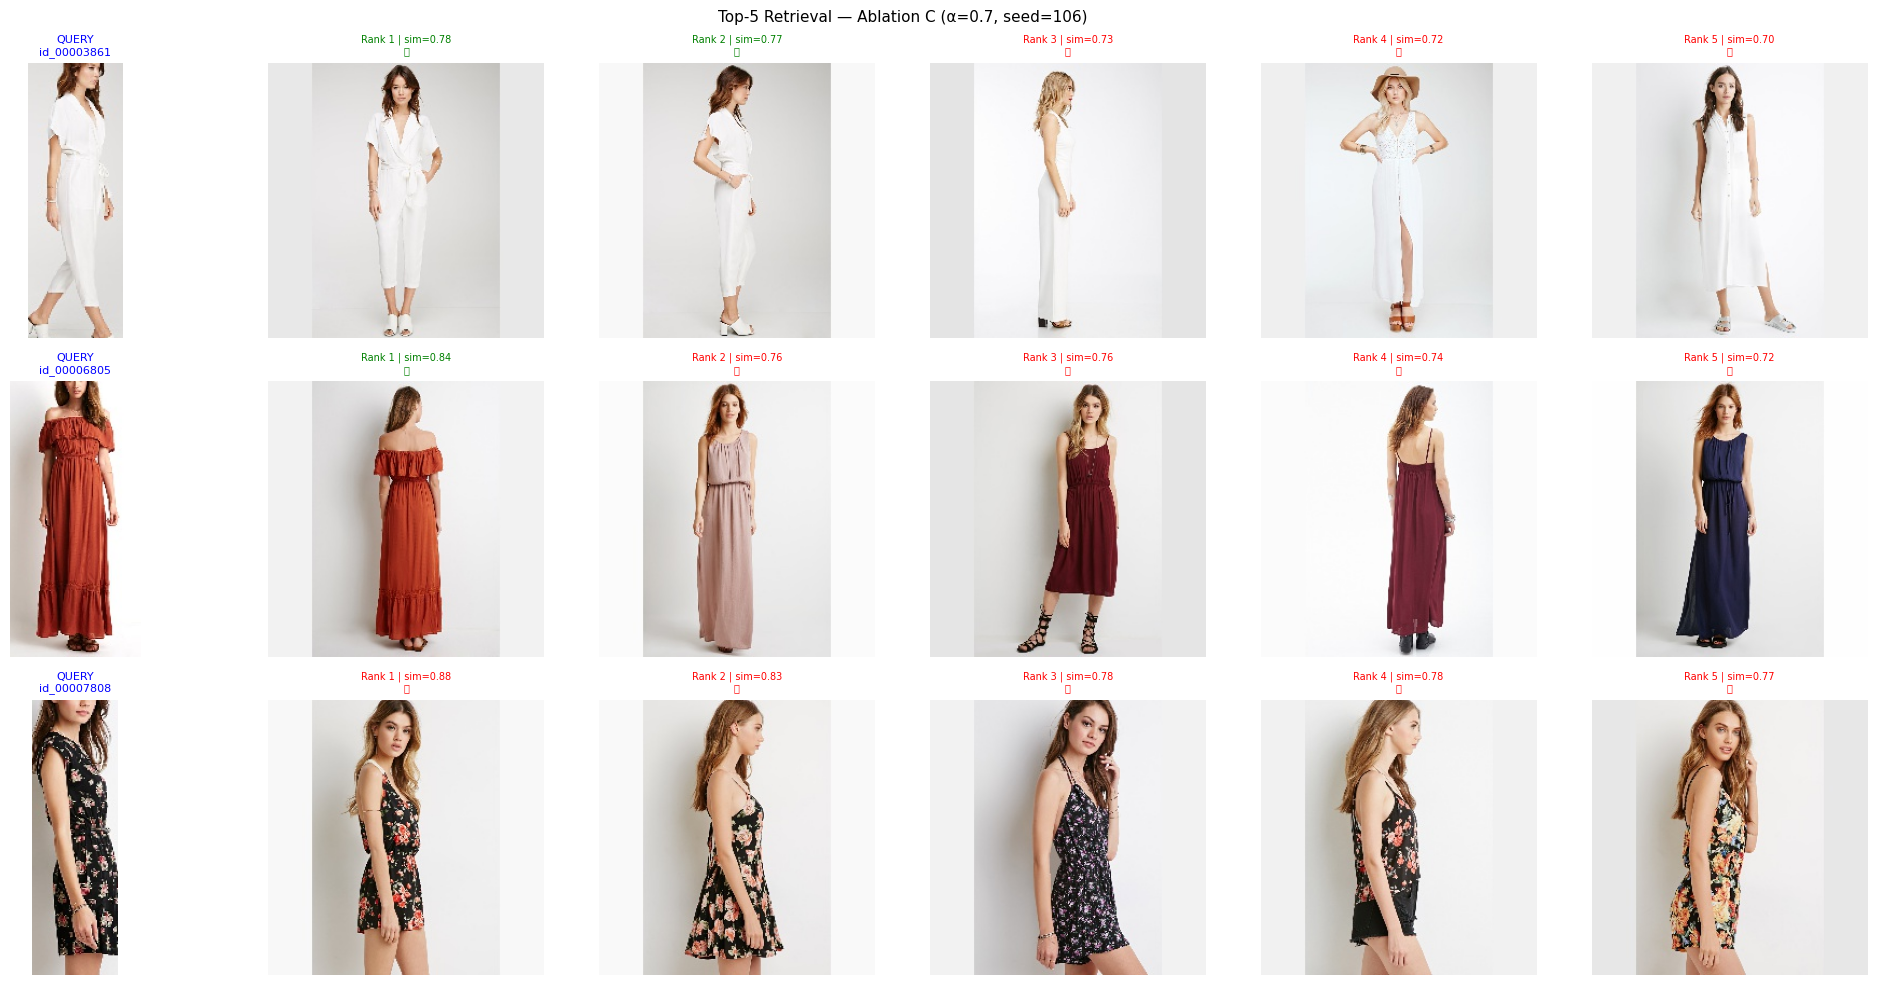


✅✅✅ EVAL C COMPLETE ✅✅✅
Save this notebook output as a dataset for final_compare.py


In [13]:
# ── Visual check ──
import matplotlib.pyplot as plt
best_seed = SEEDS[-1]
best_ckpt = f'{WORK}/clip_seed{best_seed}.pt'
if os.path.exists(best_ckpt):
    best_m, best_p, _ = load_clip(ckpt=best_ckpt)
    idx_vis, meta_vis = build_index(gallery_df, best_m, best_p, 0.7, captions, f'C_a0.7_s{best_seed}')

    sample_queries = query_df.sample(3, random_state=42)
    fig, axes = plt.subplots(3, 6, figsize=(20, 10))
    for ri, (_, qrow) in enumerate(sample_queries.iterrows()):
        crop = yolo_crop(qrow['full_path'], yolo_model)
        # FIXED: Query is vision-only
        qe = get_image_emb(crop, best_m, best_p)
        labels, dists = idx_vis.knn_query(qe.reshape(1,-1), k=5)
        axes[ri][0].imshow(crop)
        axes[ri][0].set_title(f'QUERY\n{qrow["item_id"]}', fontsize=8, color='blue')
        axes[ri][0].axis('off')
        for ci, (lbl, dist) in enumerate(zip(labels[0], dists[0])):
            m = meta_vis[lbl]; img = Image.open(m['full_path']).convert('RGB')
            match = m['item_id'] == qrow['item_id']
            axes[ri][ci+1].imshow(img)
            axes[ri][ci+1].set_title(f'Rank {ci+1} | sim={1-dist:.2f}\n{"✅" if match else "❌"}',
                fontsize=7, color='green' if match else 'red')
            axes[ri][ci+1].axis('off')
    plt.suptitle('Top-5 Retrieval — Ablation C (α=0.7, seed=106)', fontsize=11)
    plt.tight_layout()
    plt.savefig(f'{WORK}/retrieval_visual.png', dpi=150, bbox_inches='tight')
    plt.show()

print('\n✅✅✅ EVAL C COMPLETE ✅✅✅')
print('Save this notebook output as a dataset for final_compare.py')
